In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression


In [3]:
from proj.features import transforms
from proj.data.storage import LocalStorage
from proj.utils.paths import find_project_root, build_paths
from proj.data.merge_helpers import *


In [4]:
repo_root = find_project_root()
paths = build_paths(repo_root)

In [5]:
style_path = os.path.join(paths['SRC'], 'proj', 'utils', 'styler.mplstyle')
plt.style.use(style_path)

In [6]:
storage = LocalStorage(base_dir=Path("../data"))


In [7]:
gold = storage.read_parquet("gold/modeling_table.parquet")


In [8]:

def _as_1d_series(y: pd.Series) -> pd.Series:
    y = y.copy()
    if not isinstance(y.index, pd.DatetimeIndex):
        raise ValueError("y must have a DatetimeIndex")
    y = y.sort_index()
    y = y.astype(float)
    y = y.replace([np.inf, -np.inf], np.nan).dropna()
    if len(y) < 100:
        raise ValueError(f"Need more data to fit Markov model. Have {len(y)} points, want 100+.")
    return y


def fit_markov_switching(
    y: pd.Series,
    k_states: int = 3,
    switching_variance: bool = True,
    trend: str = "c",
    em_iter: int = 10,
    maxiter: int = 200,
) -> dict:
    """
    Fit Markov-switching regression with optional switching variance.
    For volatility regimes, switching_variance=True is usually what you want.

    Parameters
    ----------
    y : pd.Series
        Observable series (e.g. log RV). Index should be DatetimeIndex.
    k_states : int
        Number of regimes (2 or 3 is typical).
    switching_variance : bool
        If True, each regime has its own variance (recommended).
    trend : str
        "c" includes intercept. (Usually keep this.)
    em_iter : int
        EM iterations for good starting params.
    maxiter : int
        Max optimizer iterations.

    Returns
    -------
    dict with:
      - res: fitted statsmodels result
      - filtered_probs: DataFrame of filtered regime probabilities
      - transition: ndarray (KxK)
      - next_state_probs: Series of one-step-ahead probs for each regime at last date
    """
    # y = _as_1d_series(y)

    mod = MarkovRegression(
        endog=y,
        k_regimes=k_states,
        trend=trend,
        switching_variance=switching_variance,
    )

    # EM helps stabilize fits; disp=False keeps output quiet
    res = mod.fit(em_iter=em_iter, maxiter=maxiter, disp=False)

    # Filtered probabilities: shape (T, K)
    # res.filtered_marginal_probabilities is a DataFrame indexed like y
    filtered = res.filtered_marginal_probabilities.copy()
    filtered.columns = [f"p_state_{i}" for i in range(k_states)]

    # Transition matrix: shape (K, K)
    # res.regime_transition is (K, K) for MarkovRegression
    P = np.asarray(res.regime_transition)

    # One-step-ahead state probs for NEXT period using last filtered probs
    pi_t = filtered.iloc[-1].to_numpy(dtype=float)  # length K
    pi_next = (pi_t @ P).reshape(-1)                             # length K

    next_probs = pd.Series(
        pi_next,
        index=[f"p_state_{i}_next" for i in range(k_states)],
        name="next_state_probs",
    )

    return {
        "res": res,
        "filtered_probs": filtered,
        "transition": P,
        "next_state_probs": next_probs,
    }


def label_states_by_mean(y: pd.Series, filtered_probs: pd.DataFrame) -> dict[int, str]:
    """
    Optional helper: label state ids by level (Low/Med/High) based on implied mean of y.
    This gives stable human-readable labels.

    Returns mapping: {state_id: "Low"/"Medium"/"High"/...}
    """
    y = _as_1d_series(y)
    k = filtered_probs.shape[1]

    # "Soft" mean estimate per state using posterior weights
    means = []
    for i in range(k):
        w = filtered_probs.iloc[:, i].reindex(y.index).fillna(0.0).to_numpy()
        mu = np.sum(w * y.to_numpy()) / max(np.sum(w), 1e-12)
        means.append(mu)

    order = np.argsort(means)  # low mean -> high mean
    if k == 2:
        names = ["Low", "High"]
    elif k == 3:
        names = ["Low", "Medium", "High"]
    else:
        names = [f"StateRank{i}" for i in range(k)]

    return {int(state): names[rank] for rank, state in enumerate(order)}



In [9]:
np.log(gold['rv_xle'])

timestamp
2021-01-06 21:00:00+00:00    0.067393
2021-01-07 21:00:00+00:00    0.926715
2021-01-08 21:00:00+00:00    1.183129
2021-01-11 21:00:00+00:00    0.804309
2021-01-12 21:00:00+00:00    1.245775
                               ...   
2026-01-12 21:00:00+00:00    0.120855
2026-01-13 21:00:00+00:00    1.090358
2026-01-14 21:00:00+00:00    1.845064
2026-01-15 21:00:00+00:00    0.872230
2026-01-16 21:00:00+00:00   -1.190688
Name: rv_xle, Length: 1264, dtype: float64

In [10]:
out = fit_markov_switching(np.log(gold['rv_xle']))

/home/jackyeung99/classes/proj_energy_volatility/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [11]:
res = out["res"]
filtered = out["filtered_probs"]
P = out["transition"]
next_probs = out["next_state_probs"]

print("Transition matrix (rows=from state, cols=to state):")
P_fmt = pd.DataFrame(
    P.reshape(3, 3),
    index=[f"from_{i}" for i in range(3)],
    columns=[f"to_{i}" for i in range(3)],
)


print("\nLast filtered probs (today):")
print(filtered.iloc[-1])

print("\nOne-step-ahead probs (tomorrow):")
print(next_probs)

labels = label_states_by_mean(np.log(gold['rv_xle']), filtered)
print("\nState labels by mean level of y:", labels)

# Hard labels (optional): argmax of filtered probs
hard_state_today = int(filtered.iloc[-1].to_numpy().argmax())
print("\nMost likely state today:", hard_state_today, "->", labels.get(hard_state_today, str(hard_state_today)))

Transition matrix (rows=from state, cols=to state):

Last filtered probs (today):
p_state_0    0.743671
p_state_1    0.106245
p_state_2    0.150085
Name: 2026-01-16 21:00:00+00:00, dtype: float64

One-step-ahead probs (tomorrow):
p_state_0_next    0.725469
p_state_1_next    0.131947
p_state_2_next    0.142584
Name: next_state_probs, dtype: float64

State labels by mean level of y: {0: 'Low', 1: 'Medium', 2: 'High'}

Most likely state today: 0 -> Low


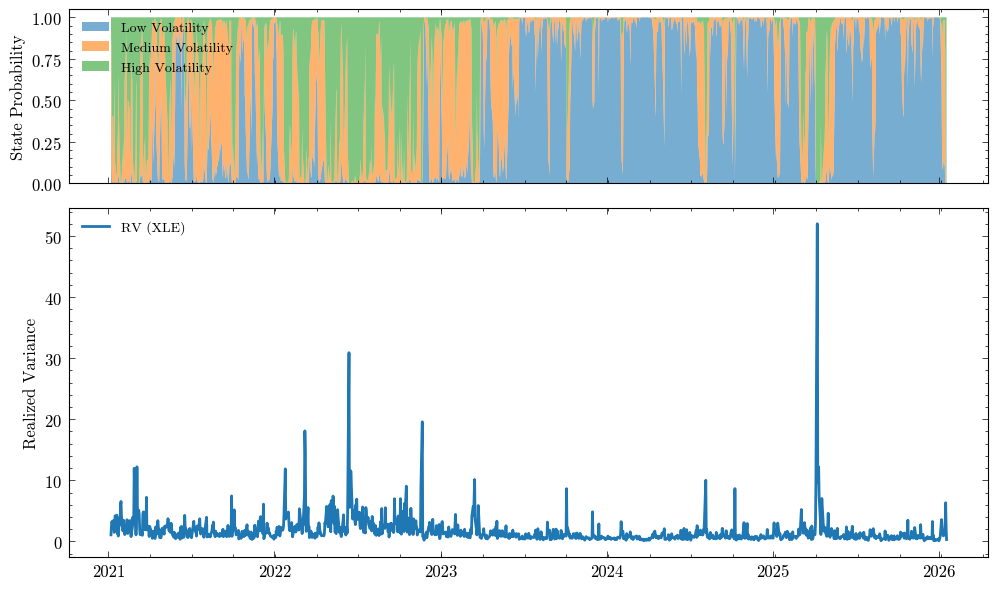

In [12]:

probs = filtered[['p_state_0','p_state_1','p_state_2']].join(gold[['rv_xle']], how='inner').dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[1, 2])

ax1.stackplot(
    probs.index,
    probs['p_state_0'],
    probs['p_state_1'],
    probs['p_state_2'],
    labels=['Low Volatility','Medium Volatility','High Volatility'],
    alpha=0.6,
)
ax1.set_ylabel("State Probability")
ax1.legend(loc="upper left")

ax2.plot(probs.index, probs['rv_xle'], linewidth=2, label="RV (XLE)")
ax2.set_ylabel("Realized Variance")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.savefig("../figures/Markov.png", dpi=300)
plt.show()
